## ***Exploratory Data Analysis of Smart Building Energy Consumption***

### **📌 Notebook Objective**

This notebook performs exploratory data analysis (EDA) on historical smart-meter data from a single building to understand energy consumption behavior, temporal patterns, and external influences such as weather and calendar effects.

The objective is to establish a clear understanding of building load characteristics, which forms the foundation for reliable short-term energy forecasting.

### **📌 Dataset Description**

The dataset contains hourly electricity consumption data collected via smart meters for a commercial building over multiple years, along with meteorological variables and holiday indicators.

Target Variable
* ENERGY — hourly electricity consumption (kWh)

Explanatory Variables
* Weather: temperature, humidity, precipitation, solar irradiance
* Degree days: heating and cooling degree indices
* Calendar: holidays

The dataset is sampled at a uniform hourly resolution, making it suitable for short-term forecasting applications.

### **📌 Initial Observations**

Initial inspection of the dataset reveals:
- Continuous hourly time series with long-term coverage
- Clear variability in energy consumption across time
- Presence of strong temporal structure typical of building loads

These observations confirm that the dataset is appropriate for time-series forecasting and operational energy analysis.

### **📌 Load Profile Analysis**

Hourly and daily load profiles highlight:
- Pronounced diurnal (24-hour) patterns
- Increased energy demand during active daytime hours
- Lower consumption during late-night periods

Such behavior reflects occupancy-driven and operational usage patterns, commonly observed in real smart buildings.

### **📌 Weekday vs Weekend Behavior**

A comparison between weekday and weekend consumption shows:
- Reduced energy usage during weekends
- More consistent and higher demand during weekdays

This confirms that **calendar effects significantly influence energy demand**, justifying the inclusion of weekday/weekend and holiday indicators in forecasting models.

### **📌 Relationship Between Weather and Energy Demand**

Scatter analysis between energy consumption and outdoor temperature indicates:
- Increased demand at higher temperatures due to cooling loads
- Weather sensitivity consistent with HVAC-dominated buildings

This validates the inclusion of weather and degree-day variables as key predictors.

### **📌 Key Takeaways**
- The building exhibits realistic operational energy behavior
- Energy demand is strongly influenced by time, weather, and calendar effects
- The dataset is well-suited for short-term hourly and daily forecasting

This EDA establishes a solid analytical foundation for feature engineering and model development.

**Import Necessary Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 5)

**Load Dataset (Building-1)**

In [ ]:
DATA_PATH = "/content/db_building_A.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,DATE,ENERGY,HDD18_3,CDD0,CDD10,PRECTOT,RH2M,T2M,T2M_MIN,T2M_MAX,ALLSKY,HOLIDAY
0,01-01-2016 00:00,NaN,11.32,6.98,0.0,10.7,90.97,6.02,1.74,12.23,1.7,1
1,01-01-2016 01:00,113.415,11.32,6.98,0.0,10.7,90.97,6.02,1.74,12.23,1.7,1
2,01-01-2016 02:00,112.431,11.32,6.98,0.0,10.7,90.97,6.02,1.74,12.23,1.7,1
3,01-01-2016 03:00,111.517,11.32,6.98,0.0,10.7,90.97,6.02,1.74,12.23,1.7,1
4,01-01-2016 04:00,117.240,11.32,6.98,0.0,10.7,90.97,6.02,1.74,12.23,1.7,1


**Timestamp Parsing & Indexing**

In [ ]:
df["DATE"] = pd.to_datetime(df["DATE"], format='mixed', dayfirst=False)
df = df.sort_values("DATE")
df = df.set_index("DATE")

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43848 entries, 2016-01-01 00:00:00 to 2020-12-31 23:00:00
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ENERGY   43746 non-null  float64
 1   HDD18_3  43848 non-null  float64
 2   CDD0     43848 non-null  float64
 3   CDD10    43848 non-null  float64
 4   PRECTOT  43848 non-null  float64
 5   RH2M     43848 non-null  float64
 6   T2M      43848 non-null  float64
 7   T2M_MIN  43848 non-null  float64
 8   T2M_MAX  43848 non-null  float64
 9   ALLSKY   43704 non-null  float64
 10  HOLIDAY  43848 non-null  int64  
dtypes: float64(10), int64(1)
memory usage: 4.0 MB


**Time Range & Missing Values**

In [ ]:
print("Start:", df.index.min())
print("End  :", df.index.max())

df.isna().sum()

Start: 2016-01-01 00:00:00
End  : 2020-12-31 23:00:00


,0
ENERGY,102
HDD18_3,0
CDD0,0
CDD10,0
PRECTOT,0
RH2M,0
T2M,0
T2M_MIN,0
T2M_MAX,0
ALLSKY,144


**Basic Statistics**

In [ ]:
df["ENERGY"].describe()

,ENERGY
count,43746.000000
mean,165.581130
std,72.326392
min,47.933000
25%,117.624250
50%,131.877500
75%,202.501750
max,469.756000


**Hourly Load Profile**

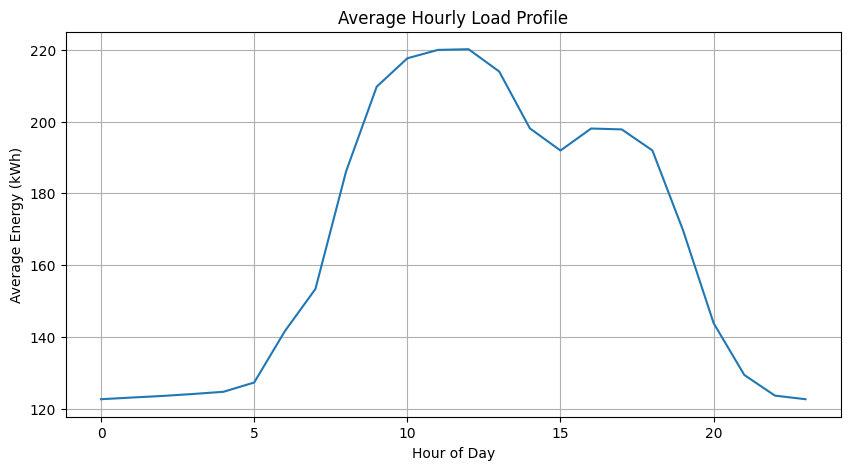

In [ ]:
hourly_profile = df.groupby(df.index.hour)["ENERGY"].mean()

plt.plot(hourly_profile)
plt.xlabel("Hour of Day")
plt.ylabel("Average Energy (kWh)")
plt.title("Average Hourly Load Profile")
plt.grid(True)
plt.show()

**Daily Energy Trend**

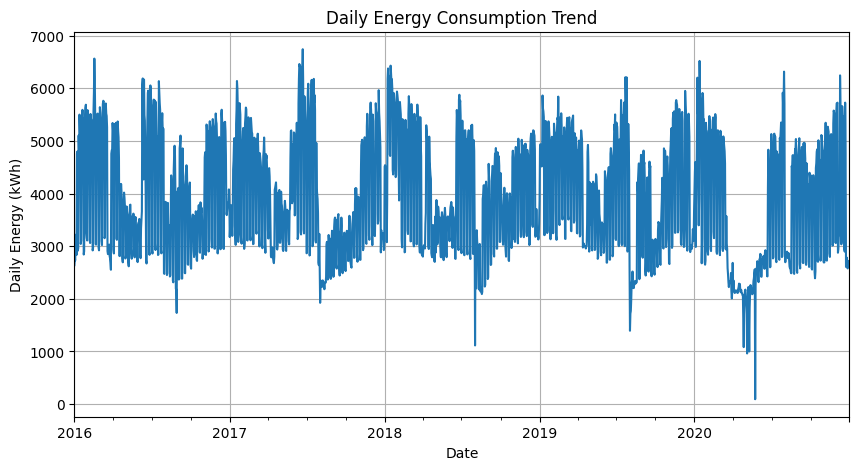

In [ ]:
daily_energy = df["ENERGY"].resample("D").sum()

daily_energy.plot()
plt.xlabel("Date")
plt.ylabel("Daily Energy (kWh)")
plt.title("Daily Energy Consumption Trend")
plt.grid(True)
plt.show()

**Weekday vs Weekend Comparison**

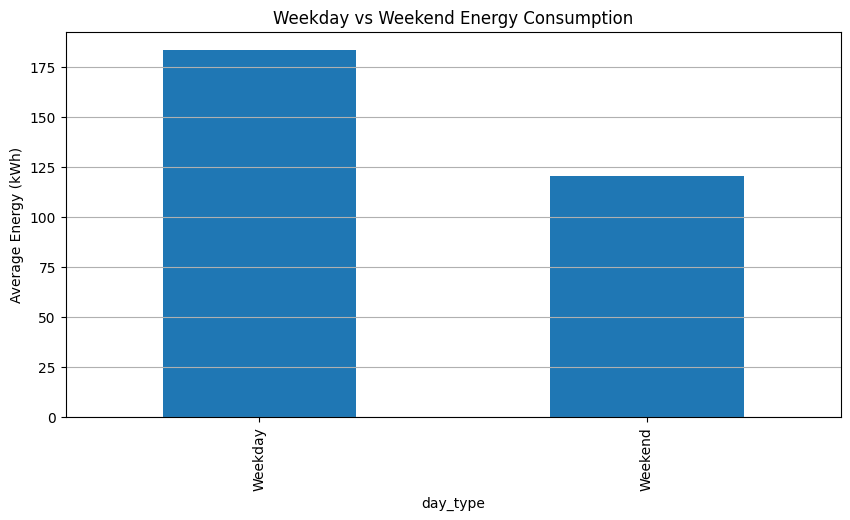

In [ ]:
df["day_type"] = np.where(df.index.dayofweek < 5, "Weekday", "Weekend")

df.groupby("day_type")["ENERGY"].mean().plot(kind="bar")
plt.ylabel("Average Energy (kWh)")
plt.title("Weekday vs Weekend Energy Consumption")
plt.grid(axis="y")
plt.show()

**Energy vs Temperature Relationship**

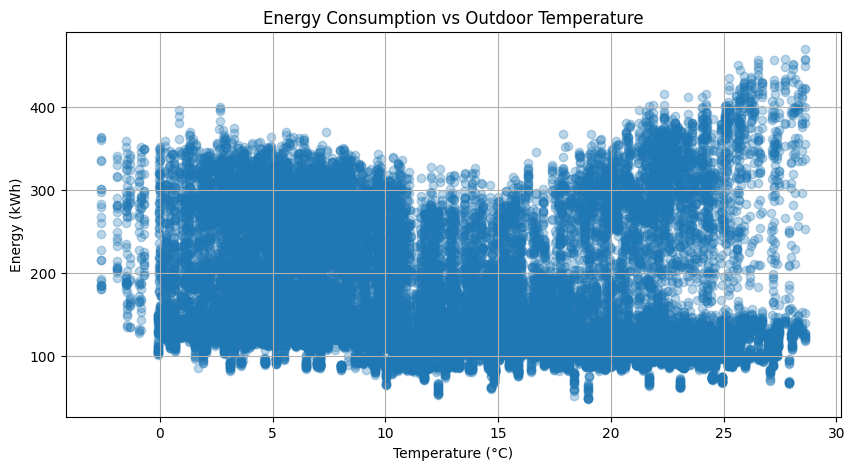

In [ ]:
plt.scatter(df["T2M"], df["ENERGY"], alpha=0.3)
plt.xlabel("Temperature (°C)")
plt.ylabel("Energy (kWh)")
plt.title("Energy Consumption vs Outdoor Temperature")
plt.grid(True)
plt.show()

**Correlation Matrix**

In [ ]:
corr_features = [
    "ENERGY", "T2M", "RH2M", "CDD10", "HDD18_3", "ALLSKY"
]

df[corr_features].corr()["ENERGY"].sort_values(ascending=False)

,ENERGY
ENERGY,1.000000
HDD18_3,0.168086
RH2M,0.102918
CDD10,-0.074264
ALLSKY,-0.115252
T2M,-0.127157
